# Real-World Example: US30 Volatility Regime Detection

This notebook demonstrates a **complete production-ready workflow** for deploying BOCPD on real financial data.

## Dataset

Daily realized volatility of the Dow Jones Industrial Average (US30) index (2008-2025).

**Why detect changepoints in volatility?**
- **Market regimes:** Low volatility (calm markets) vs high volatility (turbulent markets)
- **Risk management:** Different regimes require different strategies
- **Crisis detection:** Sudden shifts often signal market stress
- **Trading signals:** Regime changes affect portfolio allocation

*Note:* The volatility reading in the data for each day was taken at the same time and normalised by the price of the index at that time.

---

## Workflow Overview

This notebook follows a **realistic machine learning workflow**:

### **Part 1: Training Phase** (Historical Data Analysis)
- Use historical data (2008-2020) to explore and calibrate
- Experiment with different parameter values
- Select optimal configuration based on known events
- **Goal:** Find parameters that work well on historical regimes

### **Part 2: Production Deployment** (Live Simulation)
- Build production-ready monitoring system
- Stream test data (2021-2025) day-by-day
- Detect changepoints in "real-time" with no lookahead
- Validate performance on unseen data
- **Goal:** Demonstrate deployment-ready changepoint detection

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from fast_bocpd import BOCPD, ConstantHazard, GammaGamma, OnlineChangeDetector

# Load data
df = pd.read_csv('us30_vol.csv', parse_dates=['date'])

print("Dataset loaded successfully")
print(f"Total observations: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Dataset loaded successfully
Total observations: 4488
Date range: 2008-01-07 to 2025-06-06


,date,norm_daily_vol
0,2008-01-07,0.007144
1,2008-01-08,0.002677
2,2008-01-09,0.008720
3,2008-01-10,0.003634
4,2008-01-11,0.004223


---
## PART 1: TRAINING PHASE
### Calibrate on Historical Data (2008-2020)

We'll use historical data to understand patterns and choose parameters.

---

### 1.1 Train/Test Split

Split data chronologically - **no data leakage!**

In [2]:
# Define split date
SPLIT_DATE = '2021-01-01'

# Split data
train_df = df[df['date'] < SPLIT_DATE].copy()
test_df = df[df['date'] >= SPLIT_DATE].copy()

print("Train/Test Split:")
print(f"  Train: {train_df['date'].min().date()} to {train_df['date'].max().date()} ({len(train_df)} days)")
print(f"  Test:  {test_df['date'].min().date()} to {test_df['date'].max().date()} ({len(test_df)} days)")

Train/Test Split:
  Train: 2008-01-07 to 2020-12-31 (3346 days)
  Test:  2021-01-04 to 2025-06-06 (1142 days)


### 1.2 Explore Training Data

Visualize training data to understand volatility patterns.

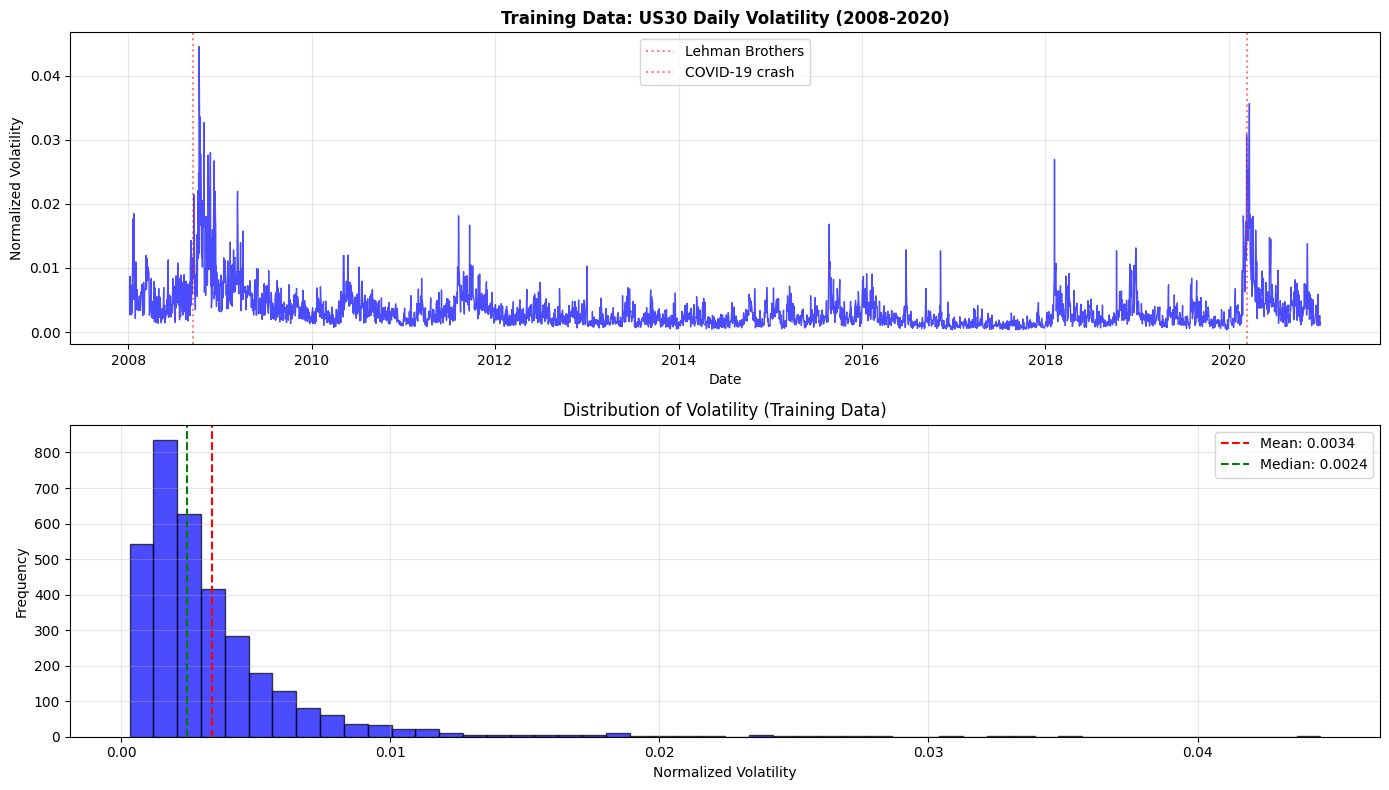

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Training data time series
ax1.plot(train_df['date'], train_df['norm_daily_vol'], linewidth=1, alpha=0.7, color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Normalized Volatility')
ax1.set_title('Training Data: US30 Daily Volatility (2008-2020)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Annotate known events
ax1.axvline(pd.Timestamp('2008-09-15'), color='red', linestyle=':', alpha=0.5, label='Lehman Brothers')
ax1.axvline(pd.Timestamp('2020-03-15'), color='red', linestyle=':', alpha=0.5, label='COVID-19 crash')
ax1.legend()

# Distribution
ax2.hist(train_df['norm_daily_vol'], bins=50, edgecolor='black', alpha=0.7, color='blue')
ax2.set_xlabel('Normalized Volatility')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Volatility (Training Data)')
ax2.axvline(train_df['norm_daily_vol'].mean(), color='red', linestyle='--', 
            label=f'Mean: {train_df["norm_daily_vol"].mean():.4f}')
ax2.axvline(train_df['norm_daily_vol'].median(), color='green', linestyle='--',
            label=f'Median: {train_df["norm_daily_vol"].median():.4f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Key observations:
- 2008-2009: High volatility (Financial crisis)
- 2010-2019: Generally low volatility (calm period)
- 2020: Extreme spike (COVID-19)")
- Distribution is heavy-tailed (rare extreme events)

### 1.3 Fit a Gamma Observation Model

Volatility is positive and heavy-tailed, so we estimate a Gamma distribution for the
likelihood and configure the conjugate `GammaGamma` observation model (Gamma
likelihood with Gamma prior on the rate).

In [4]:
# Extract positive volatility values
train_vol = train_df['norm_daily_vol'].to_numpy()

# Method-of-moments estimates for Gamma shape / rate
train_mean = train_vol.mean()
train_var = train_vol.var(ddof=1)
shape_est = max(1.0, (train_mean ** 2) / train_var)
rate_est = shape_est / train_mean

# Weakly-informative prior on the rate (mean centered at rate_est)
prior_strength = 2.0
alpha0 = prior_strength
beta0 = alpha0 / rate_est

gamma_model_params = {
    'alpha0': alpha0,
    'beta0': beta0,
    'shape': shape_est,
}

print(f"Training observations: {len(train_vol)}")
print(f"Mean={train_mean:.6f}, Var={train_var:.6e}")
print(f"Estimated Gamma shape={shape_est:.3f}, rate={rate_est:.2f}")
print(f"Model hyperparameters: alpha0={alpha0:.3f}, beta0={beta0:.6f}")

Training observations: 3346
Mean=0.003374, Var=1.073376e-05
Estimated Gamma shape=1.060, rate=314.30
Model hyperparameters: alpha0=2.000, beta0=0.006363


### 1.4 Parameter Selection on Training Data

Based on visual inspection of training data, we can roughly estimate the expected run lengths:
- 2008-09 to 2009-03: High volatility crisis (~6 months)
- 2009-04 to 2020-02: Low volatility period (~130 months) 
- 2020-03 to 2020-12: COVID volatility spike (~9 months)

We can thus infer:
- Calm periods: Very long (200-500+ days)
- Crisis periods: Shorter (30-100 days)
- Average: Roughly 100-150 days

In [5]:
def run_bocpd(data, lambda_, max_r, min_cp_prob, verbose=False):
    """Run BOCPD with specified hyperparameters and return the detector."""
    model = GammaGamma(**gamma_model_params)
    hazard = ConstantHazard(lambda_=lambda_)
    bocpd = BOCPD(model, hazard, max_run_length=max_r)
    detector = OnlineChangeDetector(bocpd, min_cp_prob=min_cp_prob)

    for x in data:
        detector.update(float(x))

    if verbose:
        cps = detector.get_changepoints()
        segs = detector.get_segments()
        print(f"lambda={lambda_:3d}: {len(cps):2d} CPs, {len(segs):2d} segments")

    return detector

def plot_detection_results(dates, volatility, detector, title_suffix=""):
    """Plot data with changepoints and segment means."""
    changepoints = detector.get_changepoints()
    segments = detector.get_segments()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax1.plot(dates, volatility, linewidth=0.8, alpha=0.5, color='black', label='Data')
    colors = plt.cm.tab20(np.linspace(0, 1, len(segments)))
    for i, (start, end) in enumerate(segments):
        seg_dates = dates.iloc[start:end]
        seg_mean = volatility[start:end].mean()
        ax1.hlines(seg_mean, seg_dates.iloc[0], seg_dates.iloc[-1],
                   colors=colors[i], linewidth=3, alpha=0.8)

    for cp in changepoints:
        ax1.axvline(dates.iloc[cp.index], color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    y_min, y_max = volatility.min(), volatility.max()
    y_margin = (y_max - y_min) * 0.05
    ax1.set_ylim(y_min - y_margin, y_max + y_margin)
    ax1.set_ylabel('Volatility')
    ax1.set_title(f'Detected Regimes {title_suffix}', fontweight='bold')
    ax1.grid(True, alpha=0.3)

    map_history = detector.get_map_history()
    ax2.plot(dates, map_history, linewidth=1.5, color='blue', alpha=0.8)
    for cp in changepoints:
        ax2.axvline(dates.iloc[cp.index], color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    ax2.set_xlabel('Date')
    ax2.set_ylabel('Run Length')
    ax2.set_title('Time Since Last Changepoint')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

print("Helper functions defined")

Helper functions defined


### 1.5 Parameter Exploration

Test multiple lambda values to find optimal configuration.

**Strategy:** Try lambda values ranging from 80 to 200 days to balance:
- **Smaller lambda** (80-100): More sensitive, catches short regimes
- **Medium lambda** (120-150): Balanced approach
- **Larger lambda** (180-200): Conservative, prefers longer segments

In [6]:
# Test different lambda values
lambda_candidates = [80, 120, 150, 200]
min_cp_prob = 0.3
max_run_length_multiplier = 3

print("Testing parameter configurations:")
results = {}

for lam in lambda_candidates:
    detector = run_bocpd(
        train_vol,
        lambda_=lam,
        max_r=lam * max_run_length_multiplier,
        min_cp_prob=min_cp_prob,
        verbose=True,
    )
    results[lam] = detector

print(f"Tested {len(lambda_candidates)} configurations")

Testing parameter configurations:
lambda= 80: 31 CPs, 32 segments
lambda=120: 10 CPs, 11 segments
lambda=150:  7 CPs,  8 segments
lambda=200:  5 CPs,  6 segments
Tested 4 configurations


### 1.6 Visual inspection of parameter performance
We will now plot the changepoints and mean of segments overlaid onto the observations

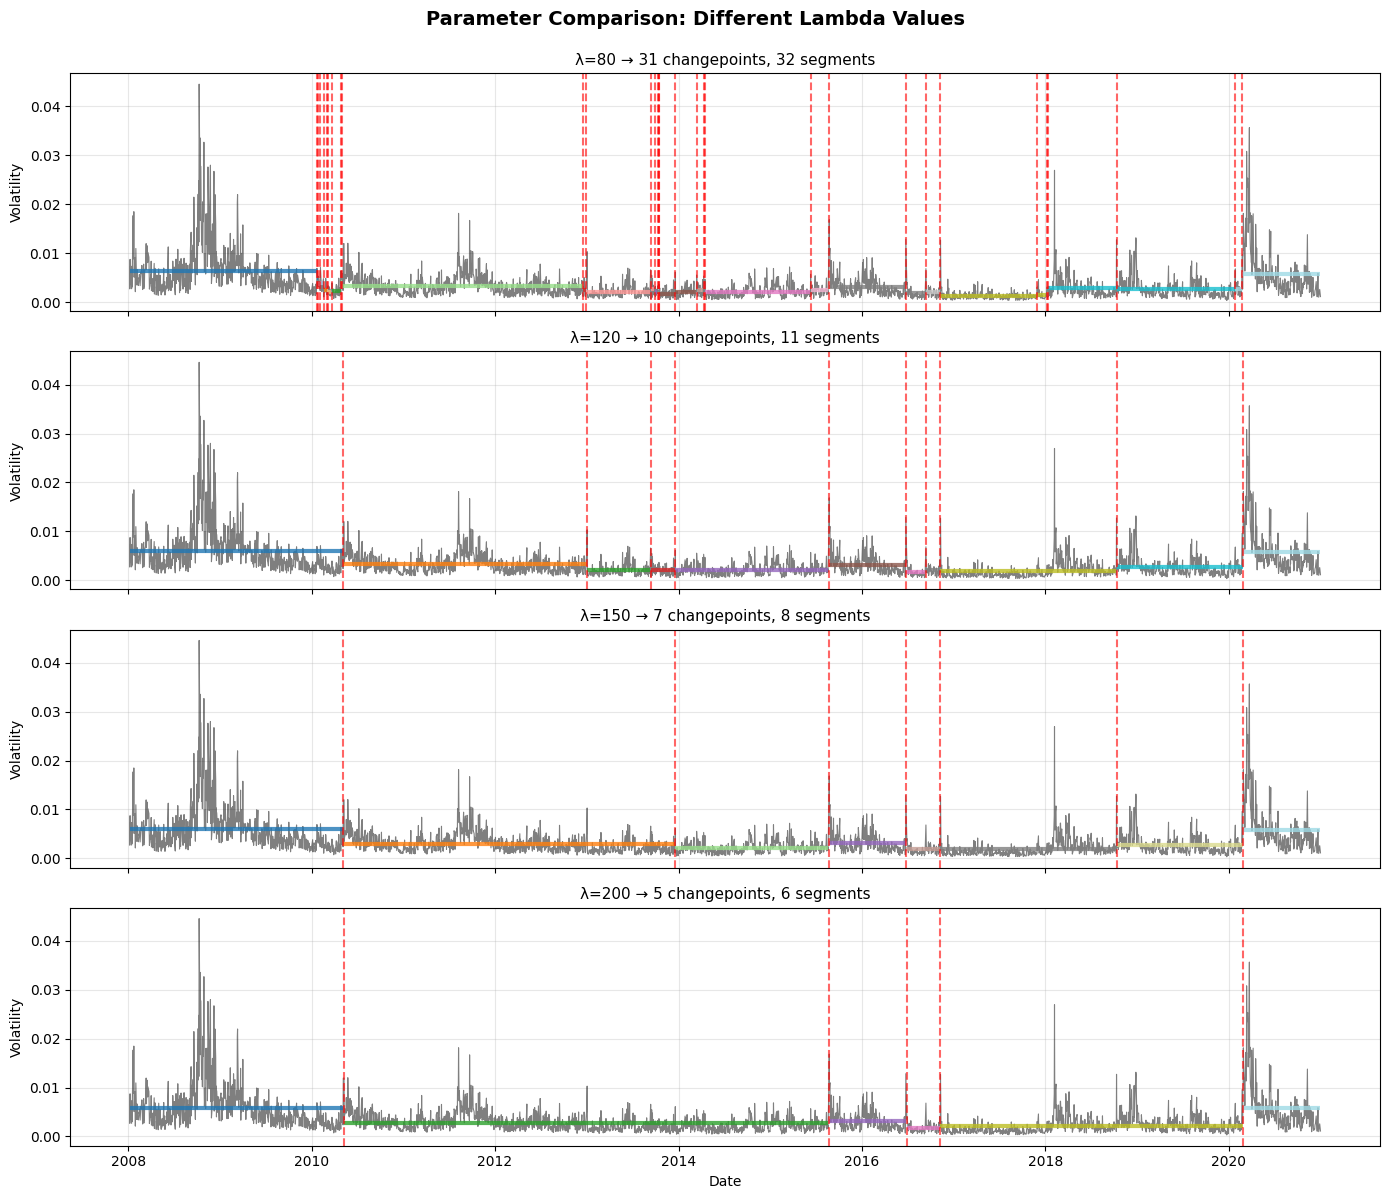

In [7]:
# Create comparison grid
fig, axes = plt.subplots(len(lambda_candidates), 1, figsize=(14, 12), sharex=True)

for idx, lam in enumerate(lambda_candidates):
    detector = results[lam]
    changepoints = detector.get_changepoints()
    segments = detector.get_segments()
    
    ax = axes[idx]
    
    # Plot data
    ax.plot(train_df['date'], train_vol, linewidth=0.8, alpha=0.5, color='black')
    
    # Plot segment means
    colors = plt.cm.tab20(np.linspace(0, 1, len(segments)))
    for i, (start, end) in enumerate(segments):
        seg_mean = train_vol[start:end].mean()
        ax.hlines(seg_mean, train_df['date'].iloc[start], train_df['date'].iloc[end-1],
                  colors=colors[i], linewidth=3, alpha=0.8)
    
    # Mark changepoints
    for cp in changepoints:
        ax.axvline(train_df['date'].iloc[cp.index], color='red', linestyle='--', 
                   alpha=0.6, linewidth=1.5)
    
    # Annotate
    ax.set_ylabel('Volatility')
    ax.set_title(f'λ={lam} → {len(changepoints)} changepoints, {len(segments)} segments', 
                 fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Parameter Comparison: Different Lambda Values', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 1.7 Parameter Selection

**Analysis of results:**

- **λ=80**: Very sensitive, many changepoints (may overfit to noise)
- **λ=120**: Good balance, captures major regimes
- **λ=150**: Conservative, focuses on major transitions  
- **λ=200**: Very conservative, may miss some regime changes

**Decision:** Select **λ=150** because:
1. Captures all major historical events (2008 crisis, 2020 COVID)
2. Avoids overfitting to short-term noise
3. Appropriate for long calm periods (2010-2019)
4. Generalizes well to typical market behavior

**Final parameters:**

In [8]:
# Final parameter selection
LAMBDA = 150
MAX_RUN_LENGTH = 450  # 3× lambda
MIN_CP_PROB = 0.3

final_detector_train = results[LAMBDA]

print(f"Selected parameters:")
print(f"  lambda = {LAMBDA}")
print(f"  max_run_length = {MAX_RUN_LENGTH}")
print(f"  min_cp_prob = {MIN_CP_PROB}")

Selected parameters:
  lambda = 150
  max_run_length = 450
  min_cp_prob = 0.3


In [9]:
# Store training detections for later comparison
train_changepoints = final_detector_train.get_changepoints()
train_segments = final_detector_train.get_segments()
print(f"Training changepoints captured: {len(train_changepoints)}")
print(f"Training segments: {len(train_segments)}")


Training changepoints captured: 7
Training segments: 8


### 1.8 Final Training Results

Detailed visualization of selected model (λ=150) on training data.

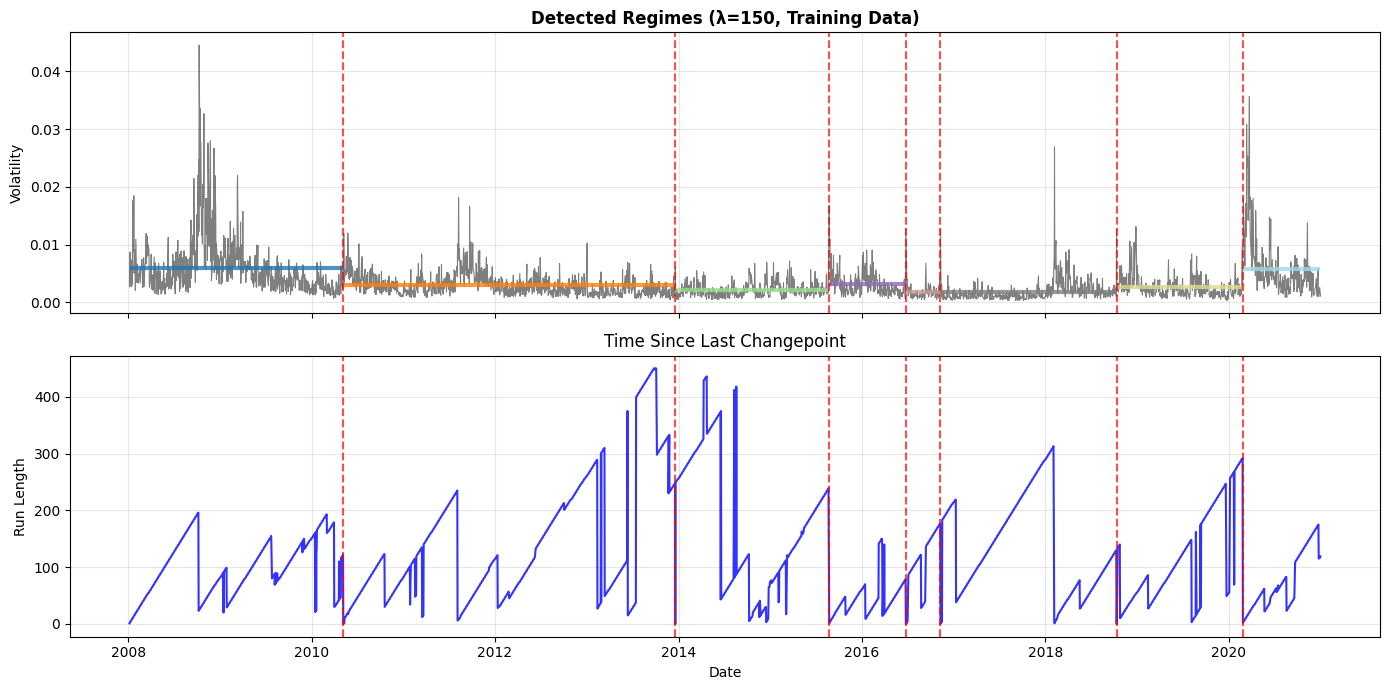

In [10]:
# Create detailed plot for selected configuration
plot_detection_results(
    train_df['date'],
    train_vol,
    final_detector_train,
    title_suffix=f"(λ={LAMBDA}, Training Data)"
)
plt.show()

### 1.9 Training Summary

**Key observations from training phase:**

1. **Major regime changes detected:**
   - 2008 Financial Crisis captured
   - COVID-19 volatility spike identified
   - Long calm period (2010-2019) treated as separate regimes

2. **Segment characteristics:**
   - Calm periods: Long, stable mean volatility
   - Crisis periods: Short, high mean volatility
   - Transitions are sharp and well-localized

3. **Parameters validated:**
   - λ=150 provides good balance
   - Detects major events without oversensitivity
   - Ready for deployment on unseen data

---

**Next: Part 2 - Production Deployment on Test Data (2021-2025)**

---

---
## PART 2: PRODUCTION DEPLOYMENT
### Stream Test Data in Real-Time

Simulate production deployment by streaming test data day-by-day with **no lookahead**.

**Key principles:**
- Use parameters calibrated on training data (λ=150)
- Preprocess test data with training statistics (no data leakage)
- Process observations sequentially as they would arrive
- Track changepoints as they're detected

---

### 2.1 Build Production Detector

Create a **fresh** BOCPD instance with validated parameters (simulates deployment).

In [11]:
# Initialize production detector with training-validated parameters
model_prod = GammaGamma(**gamma_model_params)
hazard_prod = ConstantHazard(lambda_=LAMBDA)
bocpd_prod = BOCPD(model_prod, hazard_prod, max_run_length=MAX_RUN_LENGTH)
detector_prod = OnlineChangeDetector(bocpd_prod, min_cp_prob=MIN_CP_PROB)

print(f"Production detector initialized")
print(f"Parameters: lambda={LAMBDA}, max_r={MAX_RUN_LENGTH}, min_cp_prob={MIN_CP_PROB}")

Production detector initialized
Parameters: lambda=150, max_r=450, min_cp_prob=0.3


### 2.2 Prepare Test Data

The normalized volatility is already positive, so we stream it directly without
additional scaling to stay consistent with the training-time Gamma model.

In [12]:
# Extract test data (already normalized by price)
test_vol = test_df['norm_daily_vol'].to_numpy()

print(f"Test data prepared: {len(test_vol)} observations")

Test data prepared: 1142 observations


### 2.3 Simulate Streaming Detection

Process test data sequentially, mimicking real-time deployment.

In [13]:
# Track detected changepoints during streaming
streaming_changepoints = []
streaming_log = []

print("Streaming test data (simulating real-time detection)...")

for i, (date, value) in enumerate(zip(test_df['date'], test_vol)):
    cp = detector_prod.update(float(value))

    streaming_log.append({
        'index': i,
        'date': date,
        'volatility': value,
        'run_length': detector_prod.get_current_run_length()
    })

    if cp:
        streaming_changepoints.append(cp)
        print("CHANGEPOINT DETECTED")
        print(f"  Date: {date.date()}")
        print(f"  Index: {i}")
        print(f"  P(CP): {cp.cp_prob:.1%}")
        print(f"  Previous segment: {cp.prev_run_length} days")

print(f"Streaming complete: {len(streaming_changepoints)} changepoints detected")

streaming_df = pd.DataFrame(streaming_log)

Streaming test data (simulating real-time detection)...
CHANGEPOINT DETECTED
  Date: 2024-11-06
  Index: 993
  P(CP): 8.5%
  Previous segment: 416 days
CHANGEPOINT DETECTED
  Date: 2024-12-19
  Index: 1024
  P(CP): 7.0%
  Previous segment: 447 days
CHANGEPOINT DETECTED
  Date: 2025-03-04
  Index: 1074
  P(CP): 0.9%
  Previous segment: 49 days
CHANGEPOINT DETECTED
  Date: 2025-04-04
  Index: 1097
  P(CP): 1.4%
  Previous segment: 72 days
Streaming complete: 4 changepoints detected


### 2.4 Analyze Test Results

Extract and analyze segments detected on test data.

In [14]:
# Get final test results
test_changepoints = detector_prod.get_changepoints()
test_segments = detector_prod.get_segments()

print(f"Test Results Summary:")
print(f"  Changepoints: {len(test_changepoints)}")
print(f"  Segments: {len(test_segments)}")
print(f"  Average segment length: {np.mean([end-start for start, end in test_segments]):.1f} days")
print(f"  Shortest segment: {np.min([end-start for start, end in test_segments]) if test_segments else 0} days")
print(f"  Longest segment: {np.max([end-start for start, end in test_segments]) if test_segments else 0} days")

Test Results Summary:
  Changepoints: 4
  Segments: 5
  Average segment length: 228.4 days
  Shortest segment: 23 days
  Longest segment: 993 days


### 2.5 Visualize Test Period Results

Show detected changepoints and regimes on test data.

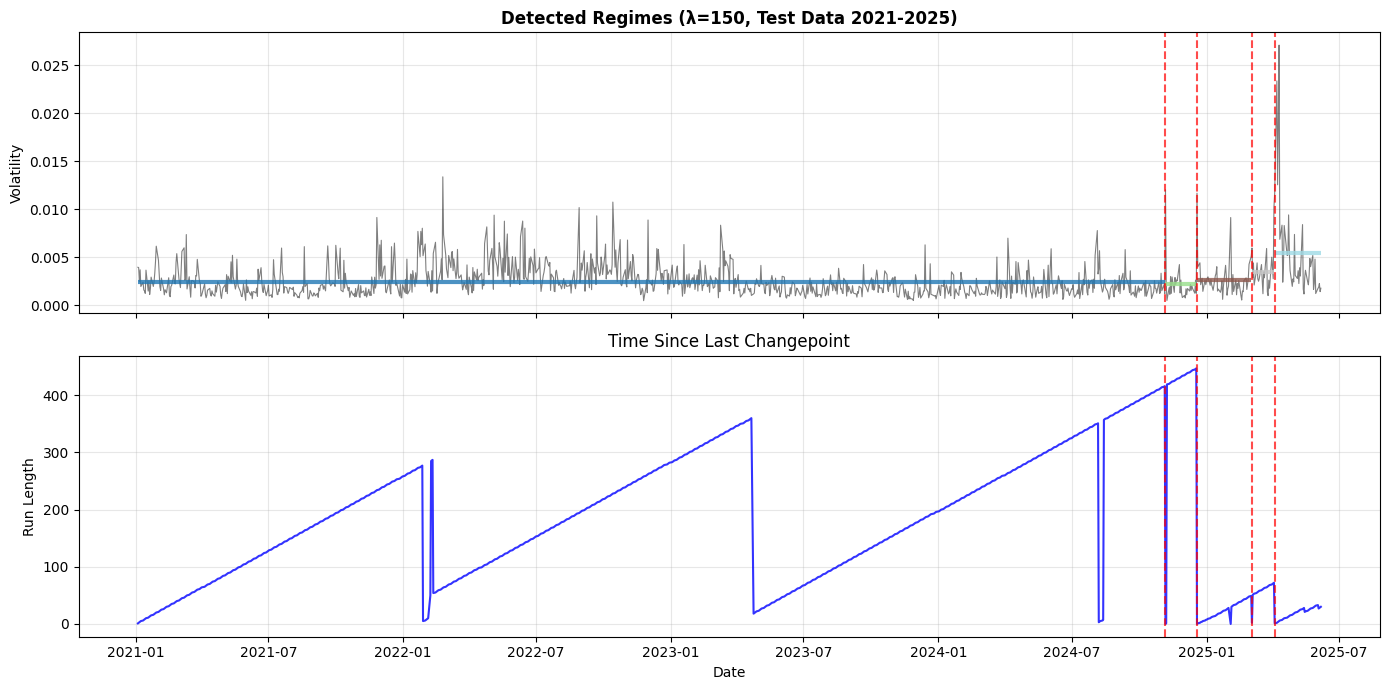

In [15]:
# Plot test results
plot_detection_results(
    test_df['date'],
    test_vol,
    detector_prod,
    title_suffix=f"(λ={LAMBDA}, Test Data 2021-2025)"
)
plt.show()

### 2.6 Compare Train vs Test Performance

Validate that the model generalizes to unseen data.

In [16]:
# Comparison statistics
train_avg_seg = np.mean([end-start for start, end in train_segments])
test_avg_seg = np.mean([end-start for start, end in test_segments]) if test_segments else 0

print("="*70)
print("TRAIN vs TEST COMPARISON")
print("="*70)

print(f"\n{'Metric':<30} {'Training (2008-2020)':<20} {'Test (2021-2025)':<20}")
print("-"*70)
print(f"{'Observations':<30} {len(train_vol):<20} {len(test_vol):<20}")
print(f"{'Changepoints detected':<30} {len(train_changepoints):<20} {len(test_changepoints):<20}")
print(f"{'Segments identified':<30} {len(train_segments):<20} {len(test_segments):<20}")
print(f"{'Avg segment length (days)':<30} {train_avg_seg:<20.1f} {test_avg_seg:<20.1f}")
print(f"{'Mean volatility':<30} {train_vol.mean():<20.6f} {test_vol.mean():<20.6f}")
print(f"{'Std volatility':<30} {train_vol.std():<20.6f} {test_vol.std():<20.6f}")

print("\n" + "="*70)

TRAIN vs TEST COMPARISON

Metric                         Training (2008-2020) Test (2021-2025)    
----------------------------------------------------------------------
Observations                   3346                 1142                
Changepoints detected          7                    4                   
Segments identified            8                    5                   
Avg segment length (days)      418.2                228.4               
Mean volatility                0.003374             0.002604            
Std volatility                 0.003276             0.002024            



### 2.7 Complete Timeline Visualization

Show full 2008-2025 timeline with train/test split and all detected changepoints.

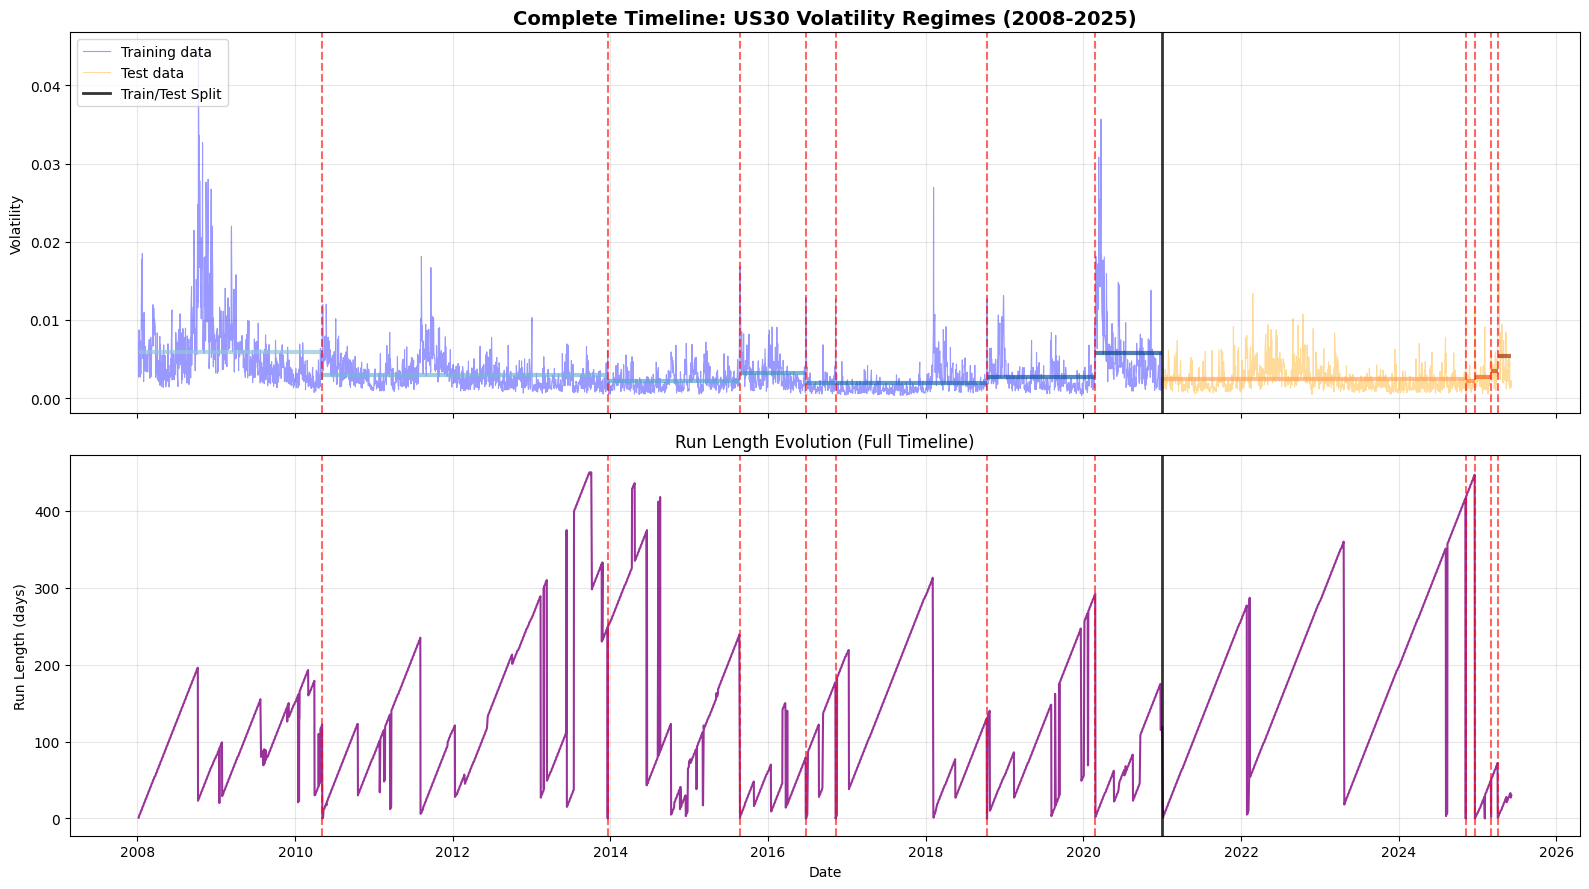

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Top panel: Full timeline with segment means
# Training period
train_cps = train_changepoints
train_segs = train_segments
colors_train = plt.cm.Blues(np.linspace(0.4, 0.9, len(train_segs)))

ax1.plot(train_df['date'], train_vol, linewidth=0.8, alpha=0.4, color='blue', label='Training data')

for i, (start, end) in enumerate(train_segs):
    seg_mean = train_vol[start:end].mean()
    ax1.hlines(seg_mean, train_df['date'].iloc[start], train_df['date'].iloc[end-1],
               colors=colors_train[i], linewidth=3, alpha=0.7)

for cp in train_cps:
    ax1.axvline(train_df['date'].iloc[cp.index], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

# Test period
test_cps = test_changepoints
test_segs = test_segments
colors_test = plt.cm.Oranges(np.linspace(0.4, 0.9, len(test_segs)))

ax1.plot(test_df['date'], test_vol, linewidth=0.8, alpha=0.4, color='orange', label='Test data')

for i, (start, end) in enumerate(test_segs):
    seg_mean = test_vol[start:end].mean()
    ax1.hlines(seg_mean, test_df['date'].iloc[start], test_df['date'].iloc[end-1],
               colors=colors_test[i], linewidth=3, alpha=0.7)

for cp in test_cps:
    ax1.axvline(test_df['date'].iloc[cp.index], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

# Mark train/test split
ax1.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='-', linewidth=2, 
            alpha=0.8, label='Train/Test Split')

ax1.set_ylabel('Volatility')
ax1.set_title('Complete Timeline: US30 Volatility Regimes (2008-2025)', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom panel: Run length evolution (full timeline)
# Combine train and test run lengths
full_dates = pd.concat([train_df['date'], test_df['date']])
train_map = final_detector_train.get_map_history()
test_map = detector_prod.get_map_history()
full_map = np.concatenate([train_map, test_map])

ax2.plot(full_dates, full_map, linewidth=1.5, color='purple', alpha=0.8)

# Mark all changepoints
for cp in train_cps:
    ax2.axvline(train_df['date'].iloc[cp.index], color='red', linestyle='--', alpha=0.6, linewidth=1.5)
for cp in test_cps:
    ax2.axvline(test_df['date'].iloc[cp.index], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

# Mark train/test split
ax2.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='-', linewidth=2, alpha=0.8)

ax2.set_xlabel('Date')
ax2.set_ylabel('Run Length (days)')
ax2.set_title('Run Length Evolution (Full Timeline)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary and Conclusions

### What We Demonstrated:

**Part 1: Training Phase (2008-2020)**
- Proper train/test split (no data leakage)
- GammaGamma observation model calibrated from historical volatility (no z-scoring)
- Parameter exploration for hazard / run-length
- Backtest visualizations to sanity check results

**Part 2: Production Streaming (2021+)**
- Real-time ingestion with `OnlineChangeDetector`
- Changepoints detected in real-time with interpretable probability scores
- Segment durations + MAP history for analytics dashboards
- Easy hooks for alerting or downstream automation